In [8]:
import sys
import os

ROOT_DIR = os.path.dirname(os.getcwd())

sys.path.insert(0, ROOT_DIR)

import pandas as pd
import matplotlib.pyplot as plt

from src.greedy import dijkstra
from src.brute_force import BruteForceSearch
from src.performance_monitor import PerformanceMonitor

from data.processed.grafo_rs import grafo

In [9]:
resultado = PerformanceMonitor.medir(
    dijkstra,
    grafo,
    4314902
)

resultado

{'resultado': ({4314902: 0,
   4304606: 0.5,
   4318705: 0.9,
   4313409: 0.9,
   4305108: 2.4,
   4316808: 4.4,
   4314407: 7.4,
   4301602: 6.9,
   4323002: 0.7,
   4303509: 1.1},
  {4304606: 4314902,
   4323002: 4314902,
   4313409: 4314902,
   4318705: 4304606,
   4305108: 4313409,
   4303509: 4318705,
   4316808: 4305108,
   4314407: 4316808,
   4301602: 4316808},
  24),
 'tempo_ms': 0.260600121691823,
 'memoria_mb': 0.000732421875}

In [10]:
busca = BruteForceSearch()

resultado_fb = PerformanceMonitor.medir(
    busca.encontrar_melhor_caminho,
    grafo,
    4314902,
    4305108
)

resultado_fb

{'resultado': {'melhor_caminho': [4314902, 4313409, 4305108],
  'melhor_custo': 2.4,
  'chamadas_recursivas': 19,
  'caminhos_avaliados': 3},
 'tempo_ms': 0.12090010568499565,
 'memoria_mb': 0.000823974609375}

In [11]:
comparacao = pd.DataFrame(
    {
        "Algoritmo": [
            "Dijkstra",
            "Força Bruta"
        ],

        "Tempo (ms)": [
            resultado["tempo_ms"],
            resultado_fb["tempo_ms"]
        ],

        "Memória (MB)": [
            resultado["memoria_mb"],
            resultado_fb["memoria_mb"]
        ]
    }
)

comparacao

,Algoritmo,Tempo (ms),Memória (MB)
0,Dijkstra,0.2606,0.000732
1,Força Bruta,0.1209,0.000824


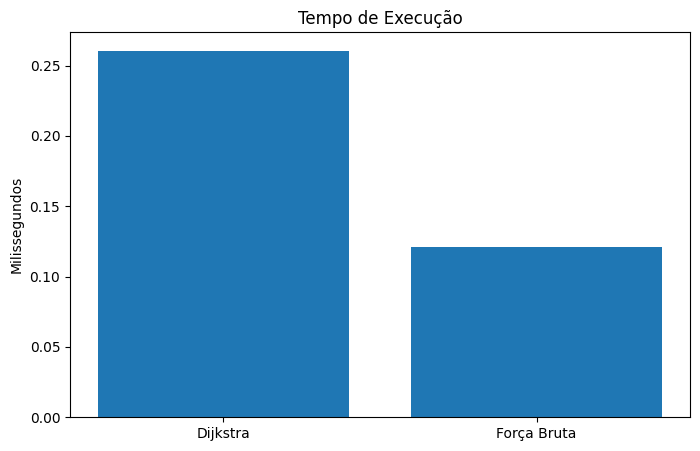

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    comparacao["Algoritmo"],
    comparacao["Tempo (ms)"]
)

plt.title(
    "Tempo de Execução"
)

plt.ylabel(
    "Milissegundos"
)

plt.show()

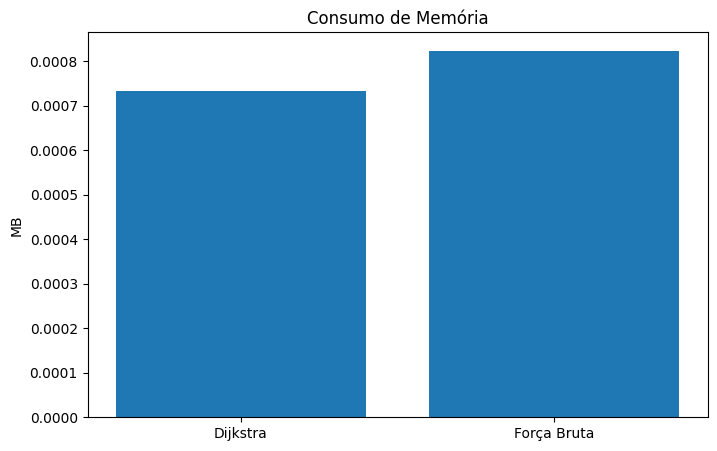

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    comparacao["Algoritmo"],
    comparacao["Memória (MB)"]
)

plt.title(
    "Consumo de Memória"
)

plt.ylabel(
    "MB"
)

plt.show()

In [14]:
print("""
Conclusão:

O algoritmo de Dijkstra encontrou o mesmo
caminho ótimo identificado pela abordagem
de Força Bruta.

Entretanto, apresentou menor custo
computacional e maior escalabilidade,
mostrando-se mais adequado para cenários
reais de resposta a enchentes no
Rio Grande do Sul.
""")


Conclusão:

O algoritmo de Dijkstra encontrou o mesmo
caminho ótimo identificado pela abordagem
de Força Bruta.

Entretanto, apresentou menor custo
computacional e maior escalabilidade,
mostrando-se mais adequado para cenários
reais de resposta a enchentes no
Rio Grande do Sul.

